In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Telco_customer_churn(Telco_Churn).csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [66]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [67]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [68]:
df.isnull().sum().sort_values(ascending=False).head(10)


Churn Reason         5174
Online Security         0
CLTV                    0
Churn Score             0
Churn Value             0
Churn Label             0
Total Charges           0
Monthly Charges         0
Payment Method          0
Paperless Billing       0
dtype: int64

In [69]:
features = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Tenure Months", "Phone Service", "Multiple Lines",
    "Internet Service", "Online Security", "Online Backup",
    "Device Protection", "Tech Support", "Streaming TV",
    "Streaming Movies", "Contract", "Paperless Billing",
    "Payment Method", "Monthly Charges", "Total Charges"
]

X = df[features].copy()
y = df["Churn Label"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [70]:
X.dtypes

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
dtype: object

In [71]:
X.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
dtype: int64

In [72]:
X["Total Charges"] = pd.to_numeric(X["Total Charges"], errors="coerce") 

print(X["Total Charges"].isnull().sum())

11


In [73]:
X["Total Charges"] = X["Total Charges"].fillna(X["Total Charges"].median())

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

/var/folders/c0/f5t2d69102zgp340ndv_6mv80000gn/T/ipykernel_20203/2971937678.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [77]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 3))

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)


Logistic Regression
Accuracy : 0.802
Precision: 0.644
Recall   : 0.57
F1 Score : 0.604
ROC-AUC  : 0.849

Random Forest
Accuracy : 0.791
Precision: 0.625
Recall   : 0.527
F1 Score : 0.572
ROC-AUC  : 0.833


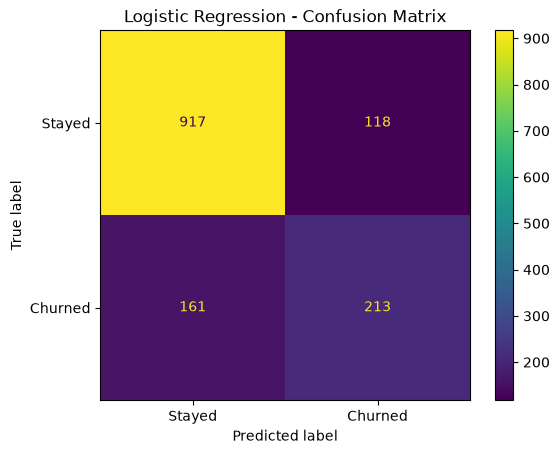

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

                 PREDICTED
              Stayed   Churned
             ┌────────┬────────┐
ACTUAL Stayed│   917  │   118  │
             │   TN   │   FP   │
             ├────────┼────────┤
ACTUAL Churn │   161  │   213  │
             │   FN   │   TP   │
             └────────┴────────┘

In [80]:
df.groupby("Contract")["Churn Value"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

In [81]:
df.groupby("Internet Service")["Churn Value"].mean()

Internet Service
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn Value, dtype: float64

In [82]:
df.groupby("Payment Method")["Churn Value"].mean()

Payment Method
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn Value, dtype: float64

In [83]:
df.groupby("Senior Citizen")["Churn Value"].mean()

Senior Citizen
No     0.236062
Yes    0.416813
Name: Churn Value, dtype: float64

In [84]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [85]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [86]:
# Threshold tuning for Logistic Regression
# (extension only: reuses y_prob_lr from above; the model and earlier results are unchanged)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
rows = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    rows.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, y_pred_t), 3),
        "Recall":    round(recall_score(y_test, y_pred_t), 3),
        "F1":        round(f1_score(y_test, y_pred_t), 3),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.20,0.479,0.861,0.616,322,350,52,685
1,0.25,0.505,0.791,0.617,296,290,78,745
2,0.30,0.532,0.746,0.621,279,245,95,790
3,0.35,0.561,0.717,0.629,268,210,106,825
4,0.40,0.579,0.674,0.623,252,183,122,852
5,0.45,0.609,0.628,0.618,235,151,139,884
6,0.50,0.644,0.570,0.604,213,118,161,917
7,0.55,0.669,0.508,0.578,190,94,184,941
8,0.60,0.721,0.441,0.547,165,64,209,971


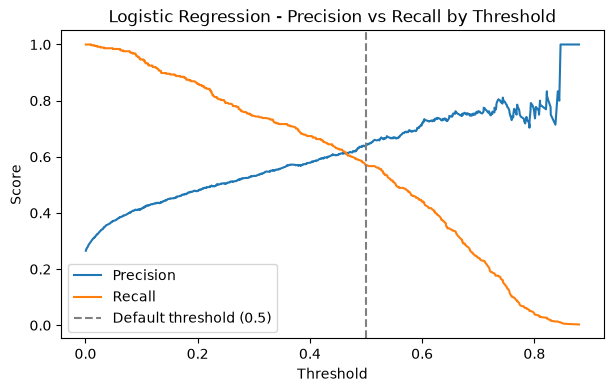

In [87]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 4))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.axvline(0.5, linestyle="--", color="gray", label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression - Precision vs Recall by Threshold")
plt.legend()
plt.show()